In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from icecream import ic
from jax import random
from jax.scipy.stats import norm
from jaxtyping import Float, Array
from tqdm import tqdm
from quadax import quadgk

from HPD_estimation_as_multiscale_Z_estimator import HPD_estimator_with_confidence, compute_bandwidth, KDE, TransformedKDE

In [3]:
GAMMA_ALPHA = 1.137527
GAMMA_BETA = 0.6899344
gamma_density = lambda x: (jnp.pow(GAMMA_BETA, GAMMA_ALPHA) / jax.scipy.special.gamma(GAMMA_ALPHA) * jnp.pow(x, GAMMA_ALPHA - 1) * jnp.exp(- GAMMA_BETA * x)) * (x > 0)
key, _ = random.split(random.key(42))
data = random.gamma(key=key, a=GAMMA_ALPHA, shape=100) / GAMMA_BETA
plot_data = jnp.linspace(-1, 5, 1000)

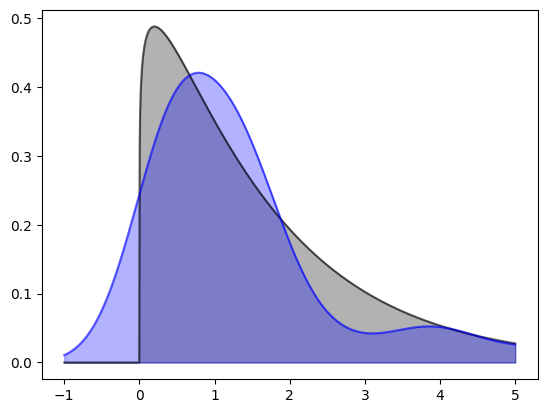

RecursionError: maximum recursion depth exceeded while calling a Python object

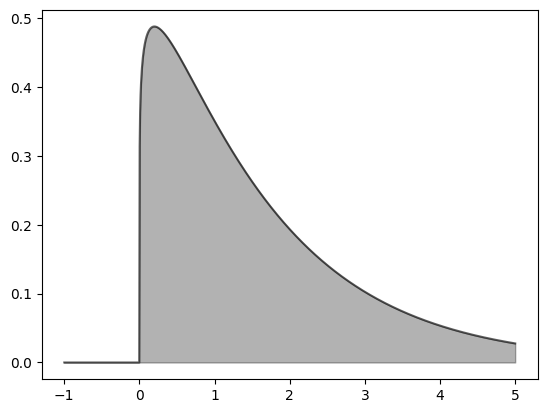

In [4]:
phi = lambda x: x
kernel = lambda x: 1/jnp.sqrt(2*jnp.pi)*jnp.exp(-x**2/2)

for _ in range(10):
    transformed_data = jax.vmap(phi)(data)
    kde_transformed_data = KDE(data=transformed_data, bandwidth=compute_bandwidth(transformed_data), kernel=kernel)
    density_estimate = TransformedKDE(kde=kde_transformed_data, phi=phi)
    plt.plot(plot_data, jax.vmap(gamma_density)(plot_data), c="k", alpha=0.6, label="true")
    plt.fill_between(plot_data, 0, jax.vmap(gamma_density)(plot_data), color="black", alpha=0.3)
    plt.plot(plot_data, jax.vmap(density_estimate)(plot_data), c="b", alpha=0.6, label="kde estimate w/ phi")
    plt.fill_between(plot_data, 0, jax.vmap(density_estimate)(plot_data), color="blue", alpha=0.3)
    plt.show()
    cdf_estimate = lambda x: quadgk(fun=density_estimate, interval=[-jnp.inf, x])[0]
    phi = lambda x: norm.ppf(cdf_estimate(x))